# 03 ESOL 数据整理：标签、重复与 scaffold

这一节把 ESOL 数据当成一个真实数据集检查，而不是直接扔给模型。重点是：
标签 `logS` 到底是什么意思、数据从哪里来、派生特征如何可追溯，以及不同 split 会支持什么样的模型声明。

## 直觉解释

AI4Chem 的第一步不是模型，而是数据。要先问：

- 标签是什么单位？
- 数据来自哪篇论文或哪个数据库？
- SMILES 能否解析？
- 是否有重复结构或近似重复结构？
- 测试集是否和训练集太像？

ESOL 是一个经典的小型水溶性数据集，常用于教学 molecular property prediction。它适合练习
descriptor、fingerprint、baseline、random split 和 scaffold split，但它不是现代部署级水溶性 benchmark。

## 数学/化学定义

ESOL 的标签是 `log solubility (mol/L)`，本课记为 `logS`：

```text
S: aqueous solubility，单位 mol/L
logS = log10(S / (1 mol/L))
```

例如 `logS = -3` 表示溶解度约为 `10^-3 mol/L`。因为很多有机小分子的水溶性低于 1 mol/L，
所以 logS 常常是负数。

本课程使用的 ESOL 数据来自 Delaney 的水溶性数据集：

> Delaney, J. S. ESOL: estimating aqueous solubility directly from molecular structure.
> Journal of Chemical Information and Computer Sciences, 2004. DOI: 10.1021/ci034243x

scaffold 是分子核心骨架的一种近似。scaffold split 会尽量让训练集和测试集包含不同骨架，
用于更严格地估计模型对新结构核心的外推能力。

## Split hierarchy：数据划分决定能支持什么声明

数据划分不是技术细节，而是在定义“模型到底学会了什么”。粗略说：

| split | 怎么划分 | 支持的结论 | 不能说明什么 |
| --- | --- | --- | --- |
| random split | 随机抽一部分做测试集 | 对同一数据分布内相似分子的插值能力 | 不能说明能外推到新骨架 |
| scaffold split | 按 Murcko scaffold 分组，让测试骨架尽量没在训练集中出现 | 对新核心骨架的初步外推能力 | 仍可能有近邻泄漏；不能说明来源/时间外推 |
| cluster split | 先按 fingerprint similarity 聚类，再按簇划分 | 比 scaffold 更直接控制结构相似度 | 聚类阈值会影响结论 |
| source split | 按实验来源、实验室、论文或 assay 分组 | 对不同实验来源/协议的鲁棒性 | ESOL 这份 CSV 缺少足够来源元数据 |
| time split | 按发表年份或数据进入数据库的时间切分 | 更接近未来部署 | 需要可靠时间戳；本课数据不具备 |
| external test | 用完全独立数据集测试 | 最接近真实泛化检查 | 成本高，且要确认标签定义一致 |

一句话：random split 只能支持“在相似数据中的插值表现”；如果要说模型能预测新骨架、新实验来源或未来数据，
就需要更强的 split 或外部测试集。本节先检查 ESOL 的结构和 scaffold 分布，后面 `04` 会做 random split 建模，
`05` 会比较 random split 和 scaffold split。

## 准备路径

这一格只负责找到 `materials/` 根目录和 `data/` 路径。这样无论从 `materials/` 还是 `notebooks/`
目录打开 notebook，后续读数据的路径都一致。

In [1]:
from pathlib import Path

START = Path.cwd().resolve()
for candidate in [START, *START.parents]:
    if (candidate / "data").exists() and (candidate / "notebooks").exists():
        ROOT = candidate
        break
else:
    raise FileNotFoundError(
        "Cannot find the materials root. Start Jupyter from the materials directory "
        "or from one of its subdirectories."
    )

DATA = ROOT / "data"
RAW = DATA / "raw"
EXAMPLES = DATA / "examples"
RANDOM_STATE = 42

# print("materials root:", ROOT)

## 准备 RDKit 工具函数

这一格定义本课程反复使用的函数：解析 SMILES、生成 canonical SMILES、计算 descriptor、
提取 Murcko scaffold，并把 ESOL 原始表转换成建模前的派生表。

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem, DataStructs
from rdkit.Chem import Crippen, Descriptors, Draw, Lipinski, rdFingerprintGenerator, rdMolDescriptors
from rdkit.Chem.Scaffolds import MurckoScaffold

sns.set_theme(style="whitegrid", context="notebook")


def mol_from_smiles(smiles):
    if pd.isna(smiles):
        return None
    return Chem.MolFromSmiles(str(smiles).strip())


def canonical_smiles(smiles):
    mol = mol_from_smiles(smiles)
    if mol is None:
        return None
    return Chem.MolToSmiles(mol)


def scaffold_smiles(mol):
    scaffold = MurckoScaffold.GetScaffoldForMol(mol)
    return Chem.MolToSmiles(scaffold)


def descriptor_record(smiles):
    mol = mol_from_smiles(smiles)
    if mol is None:
        return None
    return {
        "MolWt": Descriptors.MolWt(mol),
        "MolLogP": Crippen.MolLogP(mol),
        "TPSA": rdMolDescriptors.CalcTPSA(mol),
        "HBD": Lipinski.NumHDonors(mol),
        "HBA": Lipinski.NumHAcceptors(mol),
        "RotatableBonds": Lipinski.NumRotatableBonds(mol),
        "RingCount": rdMolDescriptors.CalcNumRings(mol),
        "AromaticRings": rdMolDescriptors.CalcNumAromaticRings(mol),
        "FractionCSP3": rdMolDescriptors.CalcFractionCSP3(mol),
        "HeavyAtomCount": Descriptors.HeavyAtomCount(mol),
        "canonical_smiles": canonical_smiles(smiles),
        "scaffold": scaffold_smiles(mol),
    }


def build_esol_features():
    raw = pd.read_csv(RAW / "esol.csv")
    rows = []
    for row_id, row in raw.reset_index(drop=True).iterrows():
        desc = descriptor_record(row["smiles"])
        if desc is None:
            continue
        desc.update(
            {
                "row_id": row_id,
                "smiles": str(row["smiles"]).strip(),
                "logS": float(row["log solubility (mol/L)"]),
            }
        )
        rows.append(desc)
    return pd.DataFrame(rows)


def fingerprint_array(smiles, n_bits=1024):
    generator = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=n_bits)
    matrix = np.zeros((len(smiles), n_bits), dtype=np.int8)
    for idx, smi in enumerate(smiles):
        fp = generator.GetFingerprint(mol_from_smiles(smi))
        DataStructs.ConvertToNumpyArray(fp, matrix[idx])
    return matrix


DESCRIPTOR_COLUMNS = [
    "MolWt",
    "MolLogP",
    "TPSA",
    "HBD",
    "HBA",
    "RotatableBonds",
    "RingCount",
    "AromaticRings",
    "FractionCSP3",
    "HeavyAtomCount",
]

## 读取 raw ESOL

先只看原始 CSV 的行数、列名和前几行。这里不做任何覆盖式修改，是为了保留 raw data 的可追溯性。

In [3]:
# raw 只包含 SMILES 和实验标签；派生列会在后面新建，不直接写回 raw CSV。
raw = pd.read_csv(RAW / "esol.csv")
print(raw.shape)
raw.head()

(1128, 2)


,smiles,log solubility (mol/L)
0,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,-0.77
1,Cc1occc1C(=O)Nc2ccccc2,-3.30
2,CC(C)=CCCC(C)=CC(=O),-2.06
3,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43,-7.87
4,c1ccsc1,-1.33


## 创建可追溯派生表

下面创建可追溯的派生表：保留原始行号，新增 canonical SMILES、descriptor 和 scaffold，不覆盖 raw CSV。

In [4]:
# build_esol_features 会跳过 RDKit 不能解析的 SMILES，并保留原始 row_id。
esol = build_esol_features()

print("raw rows:", len(raw))
print("valid molecule rows:", len(esol))
print("invalid rows:", len(raw) - len(esol))
esol[["row_id", "smiles", "canonical_smiles", "scaffold", "logS"]].head()

raw rows: 1128
valid molecule rows: 1128
invalid rows: 0


,row_id,smiles,canonical_smiles,scaffold,logS
0,0,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,N#CC(OC1OC(COC2OC(CO)C(O)C(O)C2O)C(O)C(O)C1O)c...,c1ccc(COC2CCCC(COC3CCCCO3)O2)cc1,-0.77
1,1,Cc1occc1C(=O)Nc2ccccc2,Cc1occc1C(=O)Nc1ccccc1,O=C(Nc1ccccc1)c1ccoc1,-3.30
2,2,CC(C)=CCCC(C)=CC(=O),CC(C)=CCCC(C)=CC=O,,-2.06
3,3,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43,c1ccc2c(c1)ccc1c2ccc2c3ccccc3ccc21,c1ccc2c(c1)ccc1c2ccc2c3ccccc3ccc21,-7.87
4,4,c1ccsc1,c1ccsc1,c1ccsc1,-1.33


## 检查重复结构

同一个分子可能有多种 SMILES 写法。用 canonical SMILES 分组可以发现 identity leakage 风险：
如果同一结构同时出现在 train 和 test，测试分数会被高估。

In [5]:
# canonical_smiles 相同，说明 RDKit 认为它们是同一个标准化后的分子图。
duplicate_counts = esol["canonical_smiles"].value_counts()
num_duplicate_structures = int((duplicate_counts > 1).sum())
print("duplicated canonical structures:", num_duplicate_structures)

if num_duplicate_structures:
    duplicated = esol[esol["canonical_smiles"].isin(duplicate_counts[duplicate_counts > 1].index)]
    display(duplicated.sort_values("canonical_smiles").head(10))
else:
    print("No duplicate canonical SMILES found.")

duplicated canonical structures: 11


,MolWt,MolLogP,TPSA,HBD,HBA,RotatableBonds,RingCount,AromaticRings,FractionCSP3,HeavyAtomCount,canonical_smiles,scaffold,row_id,smiles,logS
222,207.070,3.6023,0.00,0,0,0,2,2,0.000000,11,Brc1ccc2ccccc2c1,c1ccc2ccccc2c1,222,c1c(Br)ccc2ccccc12,-4.400
554,207.070,3.6023,0.00,0,0,0,2,2,0.000000,11,Brc1ccc2ccccc2c1,c1ccc2ccccc2c1,554,Brc1ccc2ccccc2c1,-4.400
213,154.253,2.7441,9.23,0,1,0,3,0,1.000000,11,CC12CCC(CC1)C(C)(C)O2,C1CC2CCC1CO2,213,CC12CCC(CC1)C(C)(C)O2,-1.640
976,154.253,2.7441,9.23,0,1,0,3,0,1.000000,11,CC12CCC(CC1)C(C)(C)O2,C1CC2CCC1CO2,976,CC12CCC(CC1)C(C)(C)O2,-1.740
232,290.447,3.9591,37.30,1,2,0,4,0,0.947368,21,CC12CCC3C(CCC4CC(O)CCC43C)C1CCC2=O,O=C1CCC2C1CCC1C3CCCCC3CCC21,232,CC34CCC1C(CCC2CC(O)CCC12C)C3CCC4=O,-4.160
655,290.447,3.9591,37.30,1,2,0,4,0,0.947368,21,CC12CCC3C(CCC4CC(O)CCC43C)C1CCC2=O,O=C1CCC2C1CCC1C3CCCCC3CCC21,655,CC12CCC(O)CC1CCC3C2CCC4(C)C3CCC4=O,-4.402
825,198.222,0.4048,75.27,2,3,2,1,0,0.666667,14,CCC1(C(C)C)C(=O)NC(=O)NC1=O,O=C1CC(=O)NC(=O)N1,825,O=C1NC(=O)NC(=O)C1(CC)C(C)C,-2.148
701,198.222,0.4048,75.27,2,3,2,1,0,0.666667,14,CCC1(C(C)C)C(=O)NC(=O)NC1=O,O=C1CC(=O)NC(=O)N1,701,CCC1(C(C)C)C(=O)NC(=O)NC1=O,-2.210
147,226.276,1.1850,75.27,2,3,4,1,0,0.727273,16,CCC1(CCC(C)C)C(=O)NC(=O)NC1=O,O=C1CC(=O)NC(=O)N1,147,CCC1(CCC(C)C)C(=O)NC(=O)NC1=O,-2.468
779,226.276,1.1850,75.27,2,3,4,1,0,0.727273,16,CCC1(CCC(C)C)C(=O)NC(=O)NC1=O,O=C1CC(=O)NC(=O)N1,779,O=C1NC(=O)NC(=O)C1(CC)CCC(C)C,-2.658


## 查看标签分布和简单趋势

这两张图回答两个基础问题：`logS` 的范围大概在哪里？分子量和水溶性有没有粗略关系？
这不是建模结论，只是帮助我们理解标签和明显异常点。

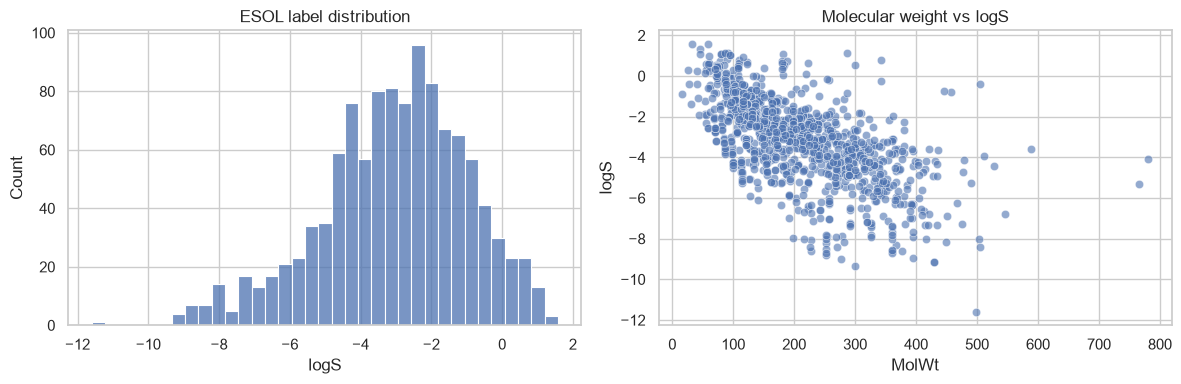

In [6]:
# 左图看标签分布，右图看一个简单 descriptor 与标签的关系。
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(esol["logS"], bins=35, ax=axes[0])
axes[0].set_title("ESOL label distribution")
axes[0].set_xlabel("logS")

sns.scatterplot(data=esol, x="MolWt", y="logS", alpha=0.6, ax=axes[1])
axes[1].set_title("Molecular weight vs logS")
plt.tight_layout()

## 查看 scaffold 分布

scaffold 分布会影响后续 split。若某个 scaffold 占比很高，random split 很可能让相似骨架同时出现在
训练集和测试集；scaffold split 则会更接近“测试新核心结构”的问题。

In [7]:
# 空 scaffold 常见于无环分子；这里把它显示成更容易读的标签。
scaffold_summary = (
    esol["scaffold"]
    .replace("", "[no ring scaffold]")
    .value_counts()
    .head(10)
    .rename_axis("scaffold")
    .reset_index(name="count")
)
scaffold_summary

,scaffold,count
0,[no ring scaffold],317
1,c1ccccc1,254
2,c1ccc(-c2ccccc2)cc1,39
3,c1ccc2ccccc2c1,22
4,O=C1CC(=O)NC(=O)N1,21
5,O=C1C=C2CCC3C4CCCC4CCC3C2CC1,17
6,c1ncncn1,16
7,c1ccncc1,14
8,c1ccc(Cc2ccccc2)cc1,12
9,C1CCCCC1,10


## 观察问题

1. ESOL 的 logS 大致分布在哪个范围？
2. 分子量和溶解度之间是否有明显趋势？有哪些例外？
3. 为什么 data card 要说明来源、单位和限制？

### Hints

1. 看 histogram 的横轴范围；多数分子 logS 为负，说明摩尔溶解度低于 1 mol/L。
2. 分子量越大通常越不易溶，但这只是弱趋势。含多个氢键供体/受体、带强极性基团或离子化状态的分子可能偏离这个趋势。
3. 来源、单位和限制决定标签是否可比较。没有 data card，就很难判断模型学到的是水溶性规律、实验来源偏差，还是数据整理过程中的偶然模式。

## 小结

数据整理不是“清洗脏数据”这么简单，而是建立可追溯的证据链。raw 数据要保留，派生特征要可复现，重复和 scaffold 会影响后续模型评价。